In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from lifelines import KaplanMeierFitter
from lifelines.plotting import add_at_risk_counts
from lifelines import CoxPHFitter
from lifelines.statistics import logrank_test
from sklearn.linear_model import LogisticRegression

pd.set_option('display.max_rows', None)

%matplotlib inline

## Read the csv and standardize column values on the overall dataframe

In [2]:
df = pd.read_csv("cleaned_dataset.csv", 
    dtype={
        "rasgef1b_mut": str,
        "hras_mut": str,
        "smarcb1_mut": str,
        "siah1_mut": str
    })

## Seperate the DataFrame

We have three different types of data in this one dataset: clinical attributes (cols: 1-31), gene expressions (cols: ), and gene mutations (cols appended with *_mut). We are going to seperate these into three different DataFrames.

In [ ]:
# Clinical attributes
clinical_cols = [
    "patient_id","age_at_diagnosis","type_of_breast_surgery","cancer_type",
    "cancer_type_detailed","cellularity","chemotherapy",
    "pam50_+_claudin-low_subtype","cohort","er_status_measured_by_ihc",
    "er_status","neoplasm_histologic_grade","her2_status_measured_by_snp6",
    "her2_status","tumor_other_histologic_subtype","hormone_therapy",
    "inferred_menopausal_state","integrative_cluster",
    "primary_tumor_laterality","lymph_nodes_examined_positive",
    "mutation_count","nottingham_prognostic_index","oncotree_code",
    "overall_survival_months","overall_survival","pr_status",
    "radio_therapy","3-gene_classifier_subtype","tumor_size",
    "tumor_stage","death_from_cancer"
]
clinical_df = df[clinical_cols].copy()

print("Clinical attributes shape:", clinical_df.shape)

Clinical attributes shape: (1904, 31)
Mutation data shape: (1904, 173)
Gene expression data shape: (1904, 487)
Number of clinical + expression + mutation columns = 691
Total columns in original df = 691


## Survival Analysis

Note: for the survival curve, we need to note the proportion of people in each category, because a 100% survival rate in a strata is not impressive if the proportion of people who are alive and in the strata is small.

In this analysis, the goal was to assess the impact of various treatments on patient survival, considering the potential confounding factors such as tumor stage, cancer type, and the presence of aggressive treatments like chemotherapy, radiotherapy, and hormone therapy.  We focused on stratifying the Kaplan-Meier survival curves by tumor stage and treatment types, which were chemotherapy, radiotherapy, and hormone therapy.

After performing exploratory data analysis (EDA) and addressing multicollinearity, the goal was observe the surival curves of patients with specific characteristics within the METABRIC study: the impact of tumor stage, cancer type, and various treatments on patient survival.

### Kaplan-Meier Curves: Stratified Comparisans

In [4]:
time_to_event = clinical_df['overall_survival_months']
event = clinical_df['event_observed']

kmf = KaplanMeierFitter()

KeyError: 'overall_survival_months'

#### a. Tumor Stage

C:\Users\calde\AppData\Local\Temp\ipykernel_36324\2266859323.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05,1))


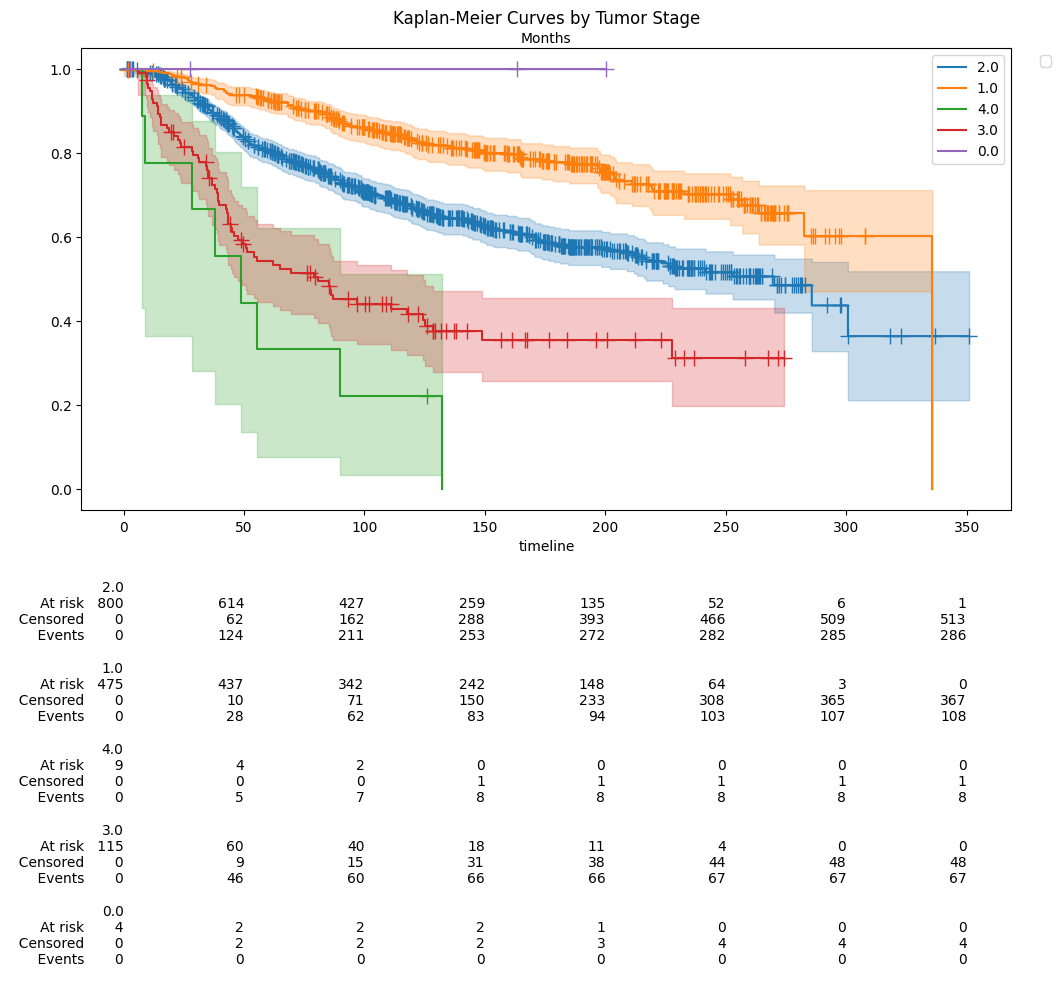

In [ ]:
plt.figure(figsize=(12,6))

ctype_fits = []

for ctype in clinical_df['tumor_stage'].dropna().unique():
    mask = clinical_df['tumor_stage'] == ctype
    kmf.fit(clinical_df['overall_survival_months'][mask], 
            event_observed=clinical_df['event_observed'][mask], 
            label=ctype)
    ax = kmf.plot_survival_function(ci_show=True, show_censors=True)
    
    ctype_fits.append(KaplanMeierFitter().fit(
        clinical_df['overall_survival_months'][mask],
        event_observed=clinical_df['event_observed'][mask],
        label=ctype
    ))

add_at_risk_counts(*ctype_fits, ax=ax)

plt.title("Kaplan-Meier Curves by Tumor Stage")
plt.xlabel("Months")
plt.ylabel("Survival Probability")
plt.legend(bbox_to_anchor=(1.05,1))
plt.show()

#### b. Cancer Type

C:\Users\calde\AppData\Local\Temp\ipykernel_36324\2093239409.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05,1))


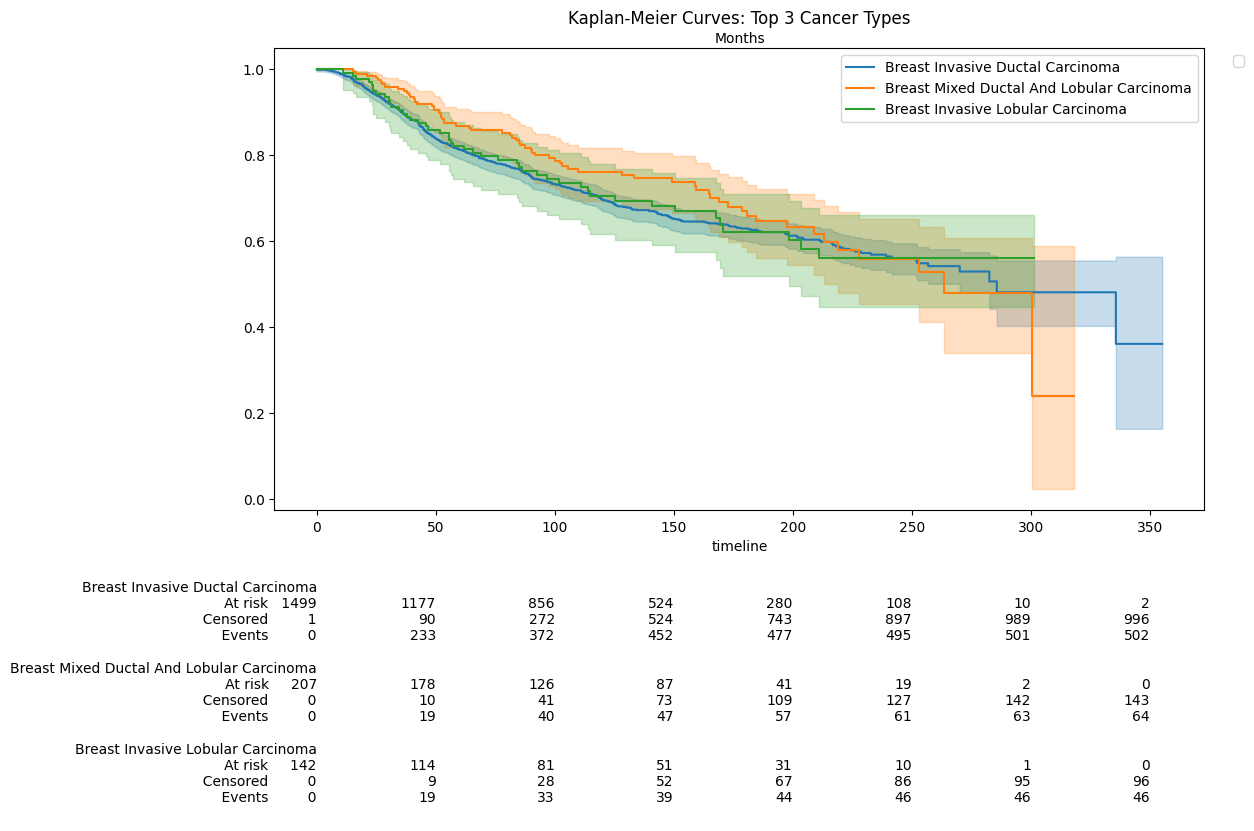

In [ ]:
top_3_types = clinical_df['cancer_type_detailed'].value_counts().nlargest(3).index.tolist()

plt.figure(figsize=(12,6))

ctype_fits = []

for ctype in top_3_types:
    mask = clinical_df['cancer_type_detailed'] == ctype
    kmf.fit(clinical_df['overall_survival_months'][mask], 
            event_observed=clinical_df['event_observed'][mask], 
            label=ctype)
    ax = kmf.plot_survival_function(ci_show=True, )
    
    ctype_fits.append(KaplanMeierFitter().fit(
        clinical_df['overall_survival_months'][mask],
        event_observed=clinical_df['event_observed'][mask],
        label=ctype
    ))

add_at_risk_counts(*ctype_fits, ax=ax)

plt.title("Kaplan-Meier Curves: Top 3 Cancer Types")
plt.xlabel("Months")
plt.ylabel("Survival Probability")
plt.legend(bbox_to_anchor=(1.05,1))
plt.show()

### Kaplan-Meier Curves and Log-Rank Test: Treatment vs No Treatment

#### a. Chemotherapy

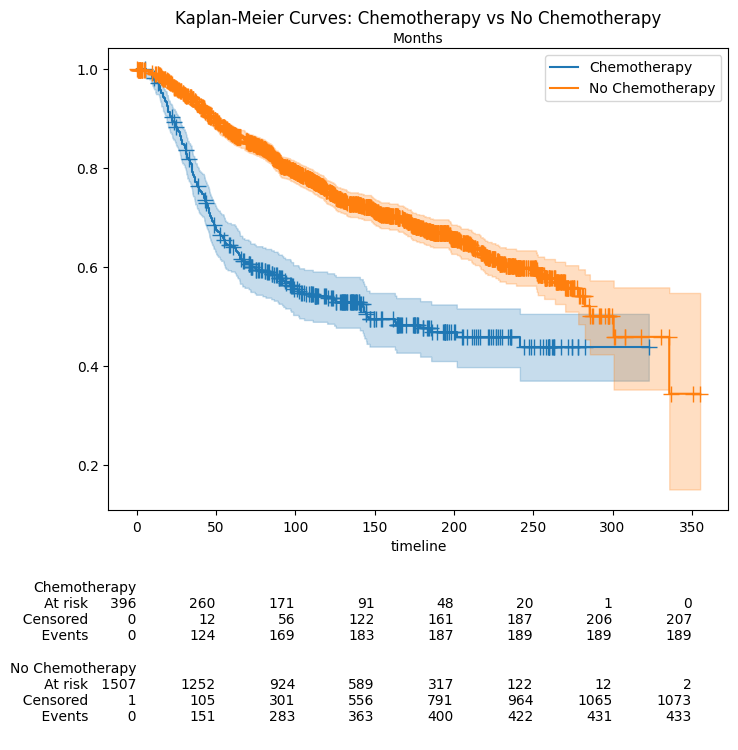

Chemotherapy Log-Rank Test p-value: 7.37161866937249e-19


In [ ]:
plt.figure(figsize=(8,6))
chemo_fits = []
for treatment, label in zip([1, 0], ['Chemotherapy', 'No Chemotherapy']):
    mask = clinical_df['chemotherapy'] == treatment
    kmf.fit(time_to_event[mask], event_observed=event[mask], label=label)
    ax = kmf.plot_survival_function(ci_show=True, show_censors=True)
    chemo_fits.append(KaplanMeierFitter().fit(time_to_event[mask], event_observed=event[mask], label=label))

add_at_risk_counts(*chemo_fits, ax=ax)
plt.title("Kaplan-Meier Curves: Chemotherapy vs No Chemotherapy")
plt.xlabel("Months")
plt.ylabel("Survival Probability")
plt.show()

# Log-rank test for chemotherapy
mask_treated = clinical_df['chemotherapy'] == 1
mask_control = clinical_df['chemotherapy'] == 0
results_chemo = logrank_test(
    time_to_event[mask_treated], 
    time_to_event[mask_control],
    event_observed_A=event[mask_treated],
    event_observed_B=event[mask_control]
)
print("Chemotherapy Log-Rank Test p-value:", results_chemo.p_value)

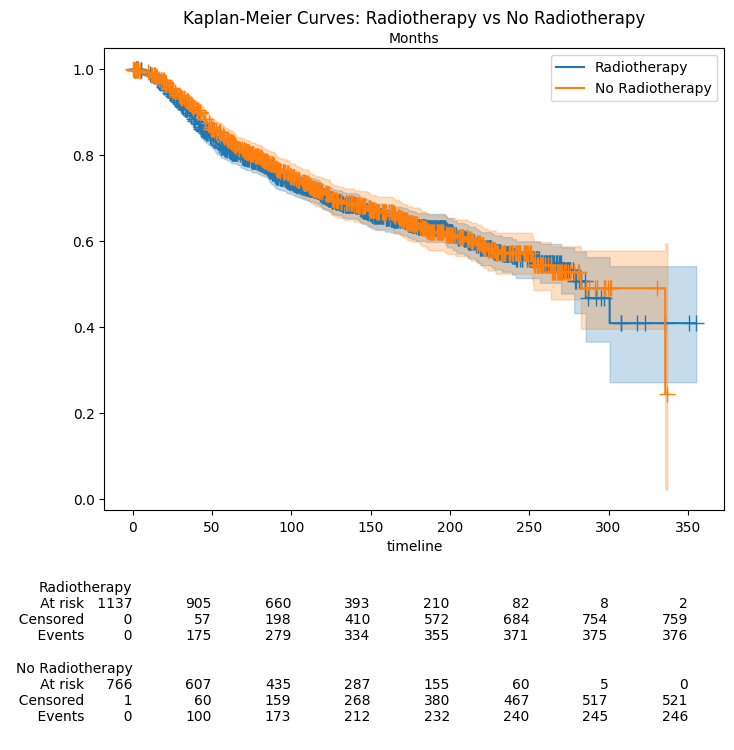

Radiotherapy Log-Rank Test p-value: 0.6696614042984366


In [ ]:
# --- Radiotherapy ---
plt.figure(figsize=(8,6))
radio_fits = []
for treatment, label in zip([1, 0], ['Radiotherapy', 'No Radiotherapy']):
    mask = clinical_df['radio_therapy'] == treatment
    kmf.fit(time_to_event[mask], event_observed=event[mask], label=label)
    ax = kmf.plot_survival_function(ci_show=True, show_censors=True)
    # Keep a fitted object for the at-risk table
    radio_fits.append(KaplanMeierFitter().fit(time_to_event[mask], event_observed=event[mask], label=label))

add_at_risk_counts(*radio_fits, ax=ax)
plt.title("Kaplan-Meier Curves: Radiotherapy vs No Radiotherapy")
plt.xlabel("Months")
plt.ylabel("Survival Probability")
plt.show()

# Log-rank test for radiotherapy
mask_treated = clinical_df['radio_therapy'] == 1
mask_control = clinical_df['radio_therapy'] == 0
results_radio = logrank_test(
    time_to_event[mask_treated], 
    time_to_event[mask_control],
    event_observed_A=event[mask_treated],
    event_observed_B=event[mask_control]
)
print("Radiotherapy Log-Rank Test p-value:", results_radio.p_value)

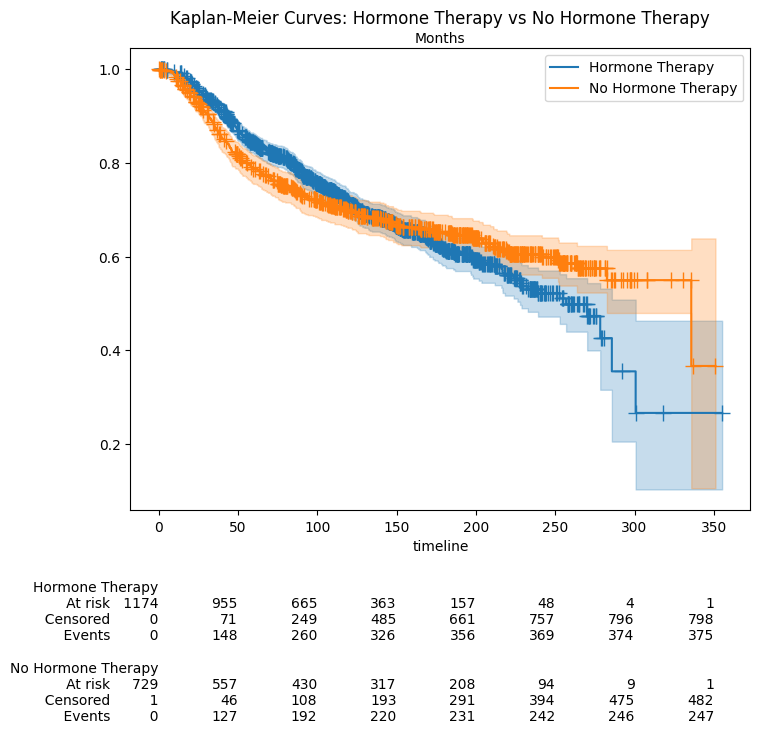

Hormone Therapy Log-Rank Test p-value: 0.722845371175301


In [ ]:

# --- Hormone therapy ---
plt.figure(figsize=(8,6))
hormone_fits = []
for treatment, label in zip([1, 0], ['Hormone Therapy', 'No Hormone Therapy']):
    mask = clinical_df['hormone_therapy'] == treatment
    kmf.fit(time_to_event[mask], event_observed=event[mask], label=label)
    ax = kmf.plot_survival_function(ci_show=True, show_censors=True)
    hormone_fits.append(KaplanMeierFitter().fit(time_to_event[mask], event_observed=event[mask], label=label))

add_at_risk_counts(*hormone_fits, ax=ax)
plt.title("Kaplan-Meier Curves: Hormone Therapy vs No Hormone Therapy")
plt.xlabel("Months")
plt.ylabel("Survival Probability")
plt.show()

# Log-rank test for hormone therapy
mask_treated = clinical_df['hormone_therapy'] == 1
mask_control = clinical_df['hormone_therapy'] == 0
results_hormone = logrank_test(
    time_to_event[mask_treated], 
    time_to_event[mask_control],
    event_observed_A=event[mask_treated],
    event_observed_B=event[mask_control]
)
print("Hormone Therapy Log-Rank Test p-value:", results_hormone.p_value)

The first Kaplan-Meier curve presented survival probabilities for patients who received chemotherapy versus those who did not. The graph showed that survival was generally lower for patients who received chemotherapy. This suggests that, at first glance, chemotherapy may not improve survival outcomes and might even be associated with poorer survival. The curves diverge early, with chemotherapy patients showing a higher rate of the death event, indicated by the steep decline in survival probability. This trend continued throughout the graph, with survival probability dropping faster in the chemotherapy group. If treatment assignment was truely independent, we would hypothesis that patients who underwent chemotherapy would have higher chances of survival. However, treatment assignment is not random. In practice, aggressive treatments (such as chemotherapy and hormone therapy) are reserved as a last resort for more aggressive cancers that do not respond to other treatments.

The third Kaplan-Meier curve compared patients receiving hormone therapy hormone therapy to those who did not. Much like the chemotherapy curve, hormone therapy patients had a similar trend of poorer survival. Again, the curve showed a faster decline in survival for patients who underwent hormone therapy, though the difference was not as extreme as in the chemotherapy graph. The statistical significance in this curve was also less pronounced, suggesting that the relationship between hormone therapy and survival may require further examination for other confounding influences, similar to chemotherapy.

In the risk counts for hormone therapy and radiotherapy, where counts between treatment/no treatment are similar, censorship greatly increases for the treatment class, which indicates a violation of the assumption of independent censorship. For chemotherapy, 

To statistically compare the survival curves, we performed log-rank tests, which test whether the differences between treated and untreated groups are significant.The log-rank test p-value was extremely small (<0.005) indicating a highly significant difference in survival. Patients who received chemotherapy had survival outcomes that differed substantially from those who did not. The p-value for radiotherapy vs. not was 0.67, showing no significant difference in survival between patients who received radiotherapy and those who did not. The p-value for hormone therapy vs. not was 0.72, also indicating no significant difference in survival between treated and untreated patients.

The next step will analyse the relationship between treatment, tumor stage and survival probability.

Tumor Stage 1 - Chemotherapy Log-Rank p-value: 0.000
Tumor Stage 2 - Chemotherapy Log-Rank p-value: 0.011
Tumor Stage 3 - Chemotherapy Log-Rank p-value: 0.210
Tumor Stage 4 - Chemotherapy Log-Rank p-value: 0.149


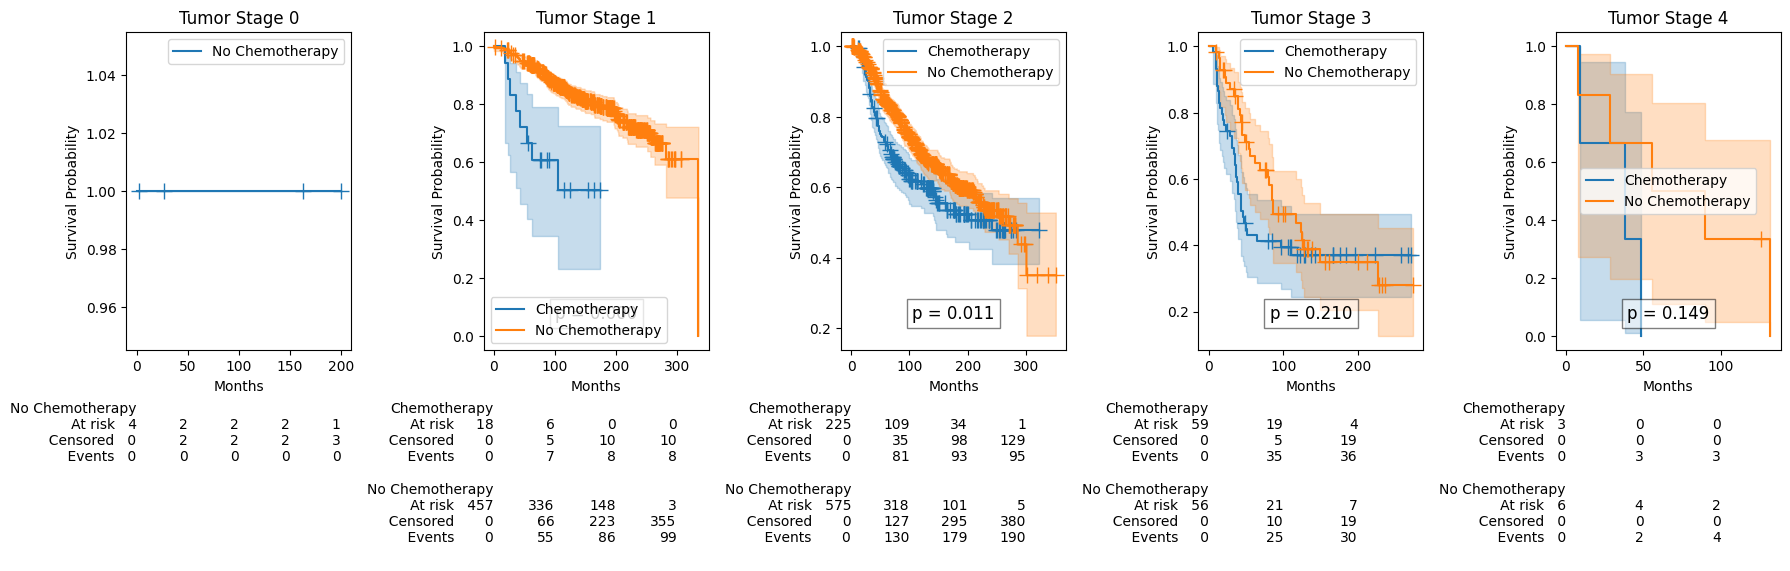

In [ ]:
from lifelines import KaplanMeierFitter
from lifelines.plotting import add_at_risk_counts
import matplotlib.pyplot as plt

# Keep only rows where stage, time_to_event, and event are numeric and not NaN
mask_valid = clinical_df['tumor_stage'].notna() & \
             pd.notna(time_to_event) & \
             pd.notna(event)

df_valid = clinical_df[mask_valid].copy()
time_to_event_valid = time_to_event[mask_valid]
event_valid = event[mask_valid]

plt.figure(figsize=(18,6))

tumor_stages = sorted(df_valid['tumor_stage'].unique())
n_stages = len(tumor_stages)

for i, stage in enumerate(tumor_stages, start=1):
    mask_stage = df_valid['tumor_stage'] == stage
    ax = plt.subplot(1, n_stages, i)
    
    stage_fits = []
    
    for treatment, label in zip([1,0], ['Chemotherapy','No Chemotherapy']):
        mask = mask_stage & (df_valid['chemotherapy'] == treatment)
        if mask.sum() == 0:
            continue
        
        # Plot survival curve
        kmf = KaplanMeierFitter()
        kmf.fit(time_to_event_valid[mask], event_observed=event_valid[mask], label=label)
        kmf.plot_survival_function(ci_show=True, ax=ax, show_censors=True)
        
        # Store for "at risk" table
        stage_fits.append(KaplanMeierFitter().fit(
            time_to_event_valid[mask],
            event_observed=event_valid[mask],
            label=label
        ))
    
    add_at_risk_counts(*stage_fits, ax=ax)
    
    ax.set_title(f"Tumor Stage {int(stage)}")
    ax.set_xlabel("Months")
    ax.set_ylabel("Survival Probability")
    
    # Log-rank test
    mask_treated = mask_stage & (df_valid['chemotherapy'] == 1)
    mask_control = mask_stage & (df_valid['chemotherapy'] == 0)
    
    if mask_treated.sum() > 0 and mask_control.sum() > 0:
        results_stage = logrank_test(
            time_to_event_valid[mask_treated],
            time_to_event_valid[mask_control],
            event_observed_A=event_valid[mask_treated],
            event_observed_B=event_valid[mask_control]
        )
        ax.text(0.5, 0.1, f"p = {results_stage.p_value:.3f}", transform=ax.transAxes,
                ha='center', fontsize=12, bbox=dict(facecolor='white', alpha=0.5))
        print(f"Tumor Stage {int(stage)} - Chemotherapy Log-Rank p-value: {results_stage.p_value:.3f}")


plt.tight_layout()
plt.show()

- At **stage 0**:
    - Any inference would be invalid due to the extremely small number of risk counts, with all observations censored.

- At **stage 1**:
    - Risk counts for participants undergoing chemotherapy is small. There is heavy censorship early for chemotherapy, while censorship gets heavier for the No Chemotherapy group later on. An interesting feature is the increase in censorship from month 100 to 200 and censorship from Stage 1, no chemotherapy subgroup. Specifically, while 14.4% of patients were censored by month 100, an additional 46.7% of those still at risk at month 100 were censored by month 200. This sharp increase suggests a loss to follow-up in non-treated patients with Stage 1 tumors. Censorship proportion increases to 89% between months 200 and 300, where month 300 is nearing the end of the study, indicating this censorship may have been administrative (patients still alive by the end of the study). 

    -  These censorship patterns are reflected in the width of the confidence intervals across the timeline. While the graph indicates participants with no chemotherapy have a significantly better survival probability - and the log-rank test confirms that the difference is statistically significant (p = 0.000), we need to consider likely selection bias (as indicated by the severe class imbalance compared to other stages), increasing censorship of non-chemotherapy patients, and unstable estimates past 100 months due to low risk counts for patients undergoing chemotherapy.

- At **stage 2**:
    - We have a more substantial population under observation, though there is still class imbalance. Censorship is high in both groups, but relatively higher for patients with chemotherapy. The difference in survival curves between the groups is visually significant (confidence intervals do not cross) for the first 100 months, while being visually insignificant past 200 months. The log-rank test confirms that the difference is statistically significant (p = 0.011).

- At **stage 3**:
    - Risk counts for participants in both groups are low. Events become comparable and there is no longer a clear visual significance between both groups. log-rank test confirms that the difference is not statistically significant (p = 0.210).

- At **stage 4**:
    - Any inference would be invalid by the extremely small amount of risk counts.


#### b. Hormone therapy

Tumor Stage 0 - Hormone Therapy Log-Rank p-value: 1.000
Tumor Stage 1 - Hormone Therapy Log-Rank p-value: 0.103
Tumor Stage 2 - Hormone Therapy Log-Rank p-value: 0.012
Tumor Stage 3 - Hormone Therapy Log-Rank p-value: 0.001
Tumor Stage 4 - Hormone Therapy Log-Rank p-value: 0.796


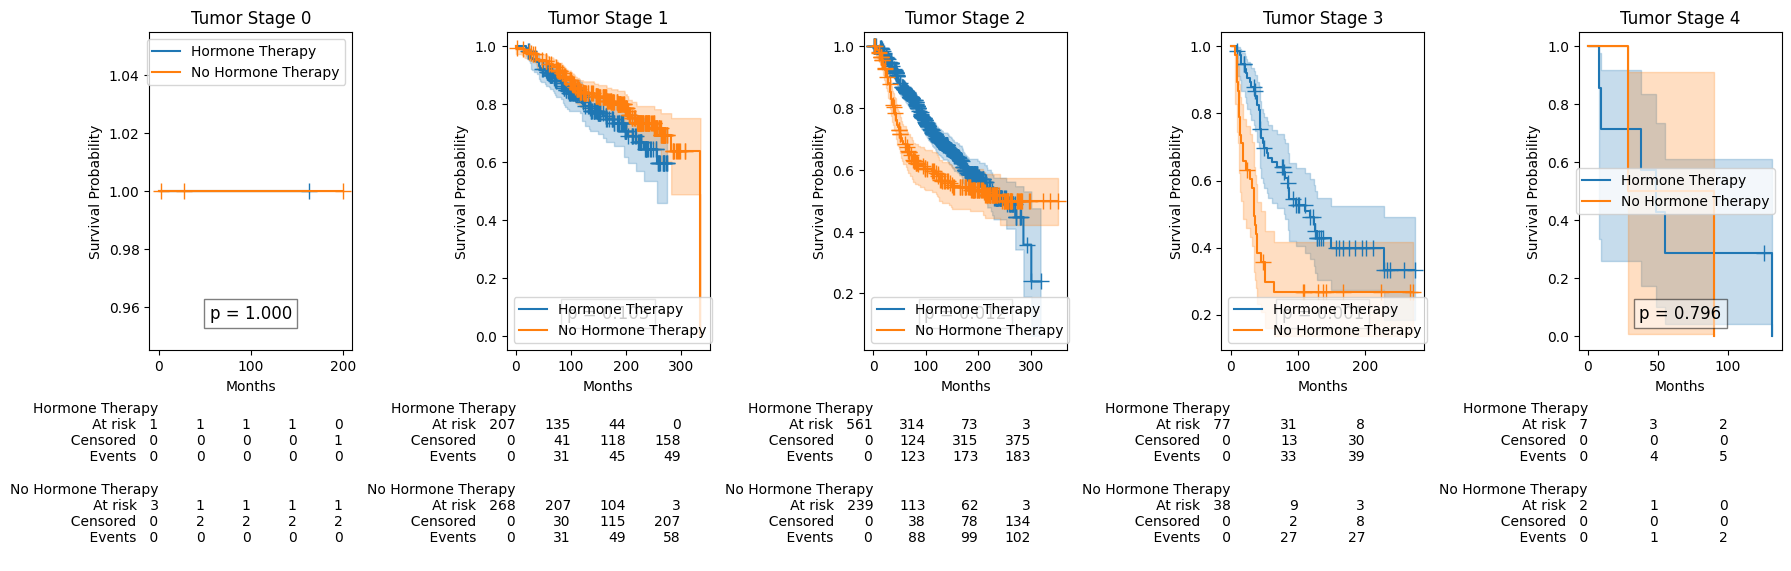

In [ ]:
from lifelines import KaplanMeierFitter
from lifelines.plotting import add_at_risk_counts
import matplotlib.pyplot as plt

# Keep only rows where stage, time_to_event, and event are numeric and not NaN
mask_valid = clinical_df['tumor_stage'].notna() & \
             pd.notna(time_to_event) & \
             pd.notna(event)

df_valid = clinical_df[mask_valid].copy()
time_to_event_valid = time_to_event[mask_valid]
event_valid = event[mask_valid]

plt.figure(figsize=(18,6))

tumor_stages = sorted(df_valid['tumor_stage'].unique())
n_stages = len(tumor_stages)

for i, stage in enumerate(tumor_stages, start=1):
    mask_stage = df_valid['tumor_stage'] == stage
    ax = plt.subplot(1, n_stages, i)
    
    stage_fits = []
    
    for treatment, label in zip([1,0], ['Hormone Therapy','No Hormone Therapy']):
        mask = mask_stage & (df_valid['hormone_therapy'] == treatment)
        if mask.sum() == 0:
            continue
        
        # Fit and plot survival curve with censored markers
        kmf = KaplanMeierFitter()
        kmf.fit(time_to_event_valid[mask], event_observed=event_valid[mask], label=label)
        kmf.plot_survival_function(ci_show=True, ax=ax, show_censors=True)
        
        # Store for "at risk" table
        stage_fits.append(KaplanMeierFitter().fit(
            time_to_event_valid[mask],
            event_observed=event_valid[mask],
            label=label
        ))
    
    add_at_risk_counts(*stage_fits, ax=ax)
    
    ax.set_title(f"Tumor Stage {int(stage)}")
    ax.set_xlabel("Months")
    ax.set_ylabel("Survival Probability")
    
    # Log-rank test
    mask_treated = mask_stage & (df_valid['hormone_therapy'] == 1)
    mask_control = mask_stage & (df_valid['hormone_therapy'] == 0)
    
    if mask_treated.sum() > 0 and mask_control.sum() > 0:
        results_stage = logrank_test(
            time_to_event_valid[mask_treated],
            time_to_event_valid[mask_control],
            event_observed_A=event_valid[mask_treated],
            event_observed_B=event_valid[mask_control]
        )
        ax.text(0.5, 0.1, f"p = {results_stage.p_value:.3f}", transform=ax.transAxes,
                ha='center', fontsize=12, bbox=dict(facecolor='white', alpha=0.5))
        print(f"Tumor Stage {int(stage)} - Hormone Therapy Log-Rank p-value: {results_stage.p_value:.3f}")


plt.tight_layout()
plt.show()

- At **stage 0**:
    - Any inference would be invalid due to the extremely small number of risk counts, with all observations censored.

- At **stage 1**:
    - Unlike chemotherapy, the classes are not notably imbalanced, leading to more comparable analysis. There is a slight increase in the survival outcomes for a patient undergoing hormone therapy than without, though it is not a notable visual difference. The log-rank test confirms that the difference is not statistically significant (p = 0.103). Again, we observe the progressive accumulation of censorship beyond 100 months.

- At **stage 2**:
    - Like the graph for Stage 2 - Chemotherapy, we have a more substantial population under observation for participants undergoing hormone therapy, but class imbalance is still present. Censorship is less prominent in hormone therapy than it is in chemotherapy, and events are more prominent in the treatment group vs. control group. While the difference in survival curves between the groups is visually significant (confidence intervals do not cross) for the first 100 months, the curve becomes less visually significant after 100 months. The log-rank test confirms that the difference is statistically significant (p = 0.012).

    - The pattern of class imbalance and increasing censorship, which was present for patients observed in our chemotherapy vs control group indicate the same confounding variables may be at play within both types of treatment.

- At **stage 3**:
    - Risk counts are lower and events become comparable for both subgroups. The survival curve indicates improved outcomes for patients receiving hormone therapy until month 100, but there is an earlier widening of confidence intervals that was not observed in the previous graphs. While the early difference in surival outcomes may be meaningful, later estimates at month 200 are unstable due to small sample size. The log-rank test confirms that the difference is statistically significant (p = 0.001).

- At **stage 4**:
    - Any inference would be invalid by the extremely small amount of risk counts.

#### c. Radiotherapy

Tumor Stage 0 - Radiotherapy Log-Rank p-value: 1.000
Tumor Stage 1 - Radiotherapy Log-Rank p-value: 0.531
Tumor Stage 2 - Radiotherapy Log-Rank p-value: 0.061
Tumor Stage 3 - Radiotherapy Log-Rank p-value: 0.859
Tumor Stage 4 - Radiotherapy Log-Rank p-value: 0.435


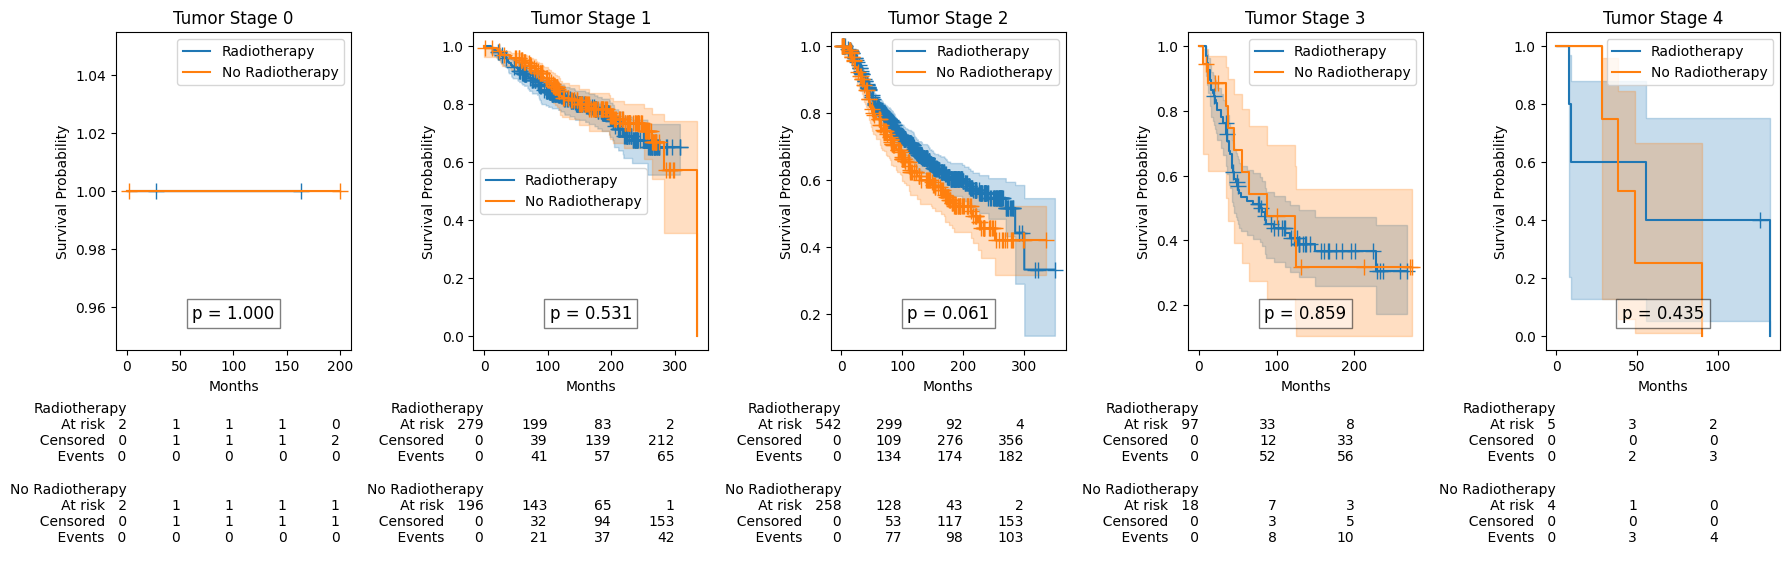

In [ ]:
from lifelines import KaplanMeierFitter
from lifelines.plotting import add_at_risk_counts
import matplotlib.pyplot as plt

# Keep only rows where stage, time_to_event, and event are numeric and not NaN
mask_valid = clinical_df['tumor_stage'].notna() & \
             pd.notna(time_to_event) & \
             pd.notna(event)

df_valid = clinical_df[mask_valid].copy()
time_to_event_valid = time_to_event[mask_valid]
event_valid = event[mask_valid]

plt.figure(figsize=(18,6))

tumor_stages = sorted(df_valid['tumor_stage'].unique())
n_stages = len(tumor_stages)

for i, stage in enumerate(tumor_stages, start=1):
    mask_stage = df_valid['tumor_stage'] == stage
    ax = plt.subplot(1, n_stages, i)
    
    stage_fits = []
    
    for treatment, label in zip([1,0], ['Radiotherapy','No Radiotherapy']):
        mask = mask_stage & (df_valid['radio_therapy'] == treatment)
        if mask.sum() == 0:
            continue
        
        # Fit and plot survival curve with censored markers
        kmf = KaplanMeierFitter()
        kmf.fit(time_to_event_valid[mask], event_observed=event_valid[mask], label=label)
        kmf.plot_survival_function(ci_show=True, ax=ax, show_censors=True)
        
        # Store for "at risk" table
        stage_fits.append(KaplanMeierFitter().fit(
            time_to_event_valid[mask],
            event_observed=event_valid[mask],
            label=label
        ))
    
    add_at_risk_counts(*stage_fits, ax=ax)
    
    ax.set_title(f"Tumor Stage {int(stage)}")
    ax.set_xlabel("Months")
    ax.set_ylabel("Survival Probability")
    
    # Log-rank test
    mask_treated = mask_stage & (df_valid['radio_therapy'] == 1)
    mask_control = mask_stage & (df_valid['radio_therapy'] == 0)
    
    if mask_treated.sum() > 0 and mask_control.sum() > 0:
        results_stage = logrank_test(
            time_to_event_valid[mask_treated],
            time_to_event_valid[mask_control],
            event_observed_A=event_valid[mask_treated],
            event_observed_B=event_valid[mask_control]
        )
        ax.text(0.5, 0.1, f"p = {results_stage.p_value:.3f}", transform=ax.transAxes,
                ha='center', fontsize=12, bbox=dict(facecolor='white', alpha=0.5))
        print(f"Tumor Stage {int(stage)} - Radiotherapy Log-Rank p-value: {results_stage.p_value:.3f}")


plt.tight_layout()
plt.show()

- At **stage 0**:
    - Any inference would be invalid due to the extremely small number of risk counts, with all observations censored.

- At **stage 1**:
    - The classes are slightly imbalanced, but there is no observable difference in the survival outcomes for a patient undergoing radiotherapy than without. The log-rank test confirms that the difference is not statistically significant (p = 0.531). Again, we observe the progressive accumulation of censorship beyond 100 months.


- At **stage 2**:
    - Like the graph for Stage 2 - Chemotherapy, we have a more substantial population under observation for participants undergoing hormone therapy, but class imbalance is still present. Censorship is less prominent in hormone therapy than it is in chemotherapy, and events are more prominent in the treatment group vs. control group. While the difference in survival curves between the groups is visually significant (confidence intervals do not cross) for the first 100 months, the curve becomes less visually significant after 100 months. The low risk counts may be a factor in the drop of visual significance.  The log-rank test confirms that the difference is statistically significant (p = 0.061).

    - The pattern of class imbalance and increasing censorship, which was present for patients observed in our chemotherapy vs control group indicate the same confounding variables may be at play within both types of treatment.

- At **stage 3**:
    - Due to the extremely small amount of risk counts in patients not undergoing radiotherapy, any inference of this group would be invalid.

    - For the limited observed patients undergoing radiotherapy between month 0 - 100, 54% of the sample encountered the event. The log-rank test confirms that the difference is not statistically significant (p = 0.859).

- At **stage 4**:
    - Any inference would be invalid by the extremely small amount of risk counts.

### Relationship Between NPI, Tumor Stage, and Treatment Type

To better understand these findings, we hypothesized that there could be a confounding relationship between tumor stage and treatment type. The confounding variable would be impacting the two more aggressive treatments: chemotherapy and hormone therapy. These two therapies are often prescribed for more advanced and severe tumor stages, potentially creating a bias where the apparent negative effect of treatment may be due to the stage of the cancer, not the treatment itself.

To illustrate this hypothesis, we plotted the Nottingham Prognostic Index (NPI) across treatment types and tumor stages. The NPI is a well-established metric for evaluating the severity and aggressiveness of a tumor and serves as a good proxy for patient survivability.

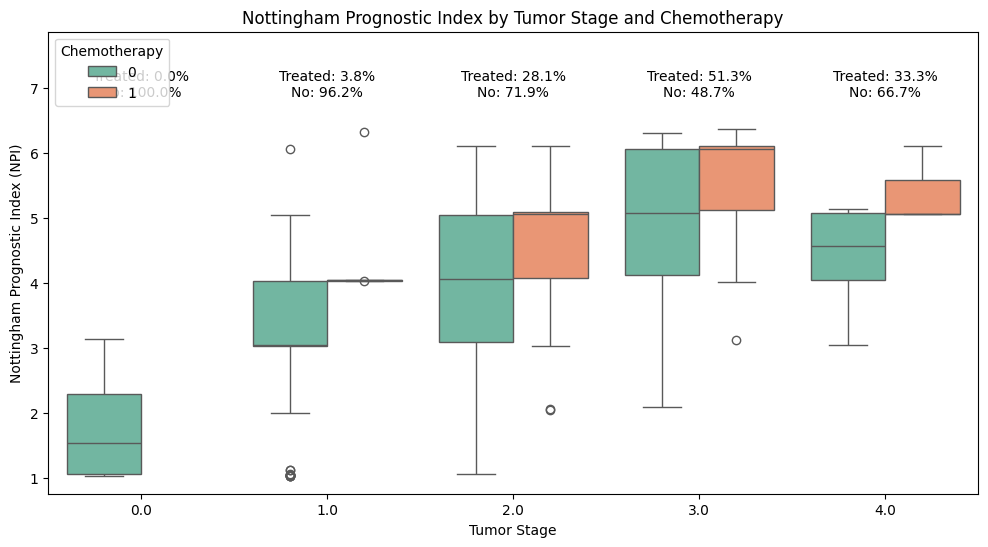

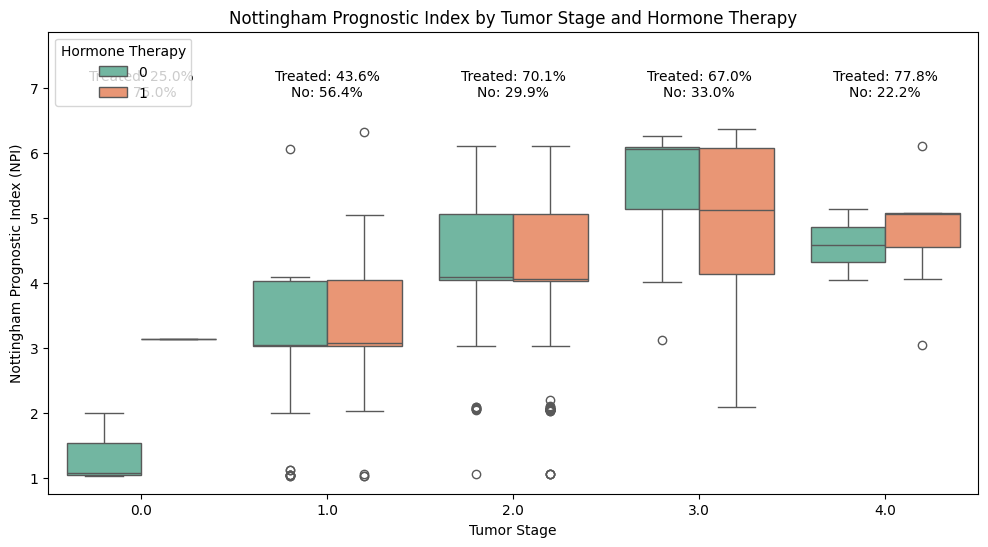

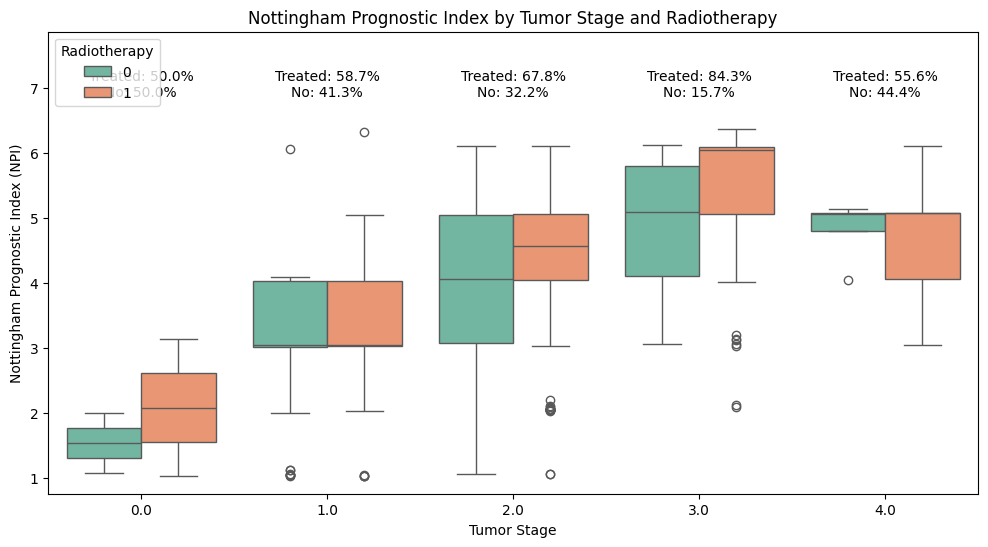

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

treatments = {
    'chemotherapy': 'Chemotherapy',
    'hormone_therapy': 'Hormone Therapy',
    'radio_therapy': 'Radiotherapy'
}

for treatment_col, treatment_name in treatments.items():
    df_plot = clinical_df.dropna(subset=[
        'nottingham_prognostic_index',
        'tumor_stage',
        treatment_col
    ])
    
    plt.figure(figsize=(12,6))
    
    ax = sns.boxplot(
        data=df_plot,
        x='tumor_stage',
        y='nottingham_prognostic_index',
        hue=treatment_col,
        palette='Set2'
    )
    
    # Compute proportions
    stage_counts = df_plot.groupby('tumor_stage')[treatment_col].value_counts().unstack().fillna(0)
    
    if 1 not in stage_counts.columns:
        stage_counts[1] = 0
    if 0 not in stage_counts.columns:
        stage_counts[0] = 0
    
    stage_totals = stage_counts.sum(axis=1)
    
    prop_treated = stage_counts[1] / stage_totals
    prop_not = stage_counts[0] / stage_totals
    
    # Annotate proportions
    for i, stage in enumerate(stage_counts.index):
        treated_pct = prop_treated.loc[stage] * 100
        not_pct = prop_not.loc[stage] * 100
        
        ax.text(
            i, 
            df_plot['nottingham_prognostic_index'].max() + 0.5,
            f"Treated: {treated_pct:.1f}%\nNo: {not_pct:.1f}%",
            ha='center',
            fontsize=10
        )
    
    plt.title(f"Nottingham Prognostic Index by Tumor Stage and {treatment_name}")
    plt.xlabel("Tumor Stage")
    plt.ylabel("Nottingham Prognostic Index (NPI)")
    plt.legend(title=treatment_name, loc='upper left')
    
    plt.ylim(top=df_plot['nottingham_prognostic_index'].max() + 1.5)
    
    plt.show()

These boxplots revealed that treatment type varied significantly by tumor stage: patients with more advanced tumors were more likely to have undergone aggressive treatments. This raised a crucial point that needs further investigation: did the worse survival outcomes seen in the treatment groups actually reflect the severity of the cancer rather than the treatment's effectiveness?

### Cox Model

To determine whether the treatment effects were truly influenced by the treatments themselves or by confounding variables such as tumor stage, we performed Cox proportional hazards modeling. As learned in class, the Cox model estimates the hazard, or instantaneous risk, of experiencing an event at any given time, based on the patient's characteristics and treatment status. By modeling the hazard as a function of covariates, the Cox model provides hazard ratios, which quantify how the risk of the event changes with treatment or other predictors. For example, a hazard ratio less than 1 for a treatment indicates a reduction in risk, whereas a hazard ratio greater than 1 indicates an increased risk.

In [ ]:
import pandas as pd
from lifelines import CoxPHFitter

# Select relevant covariates
covariates = [
    'chemotherapy', 'hormone_therapy', 'radio_therapy',
    'tumor_stage', 'age_at_diagnosis',
    'er_status', 'pr_status', 'her2_status',
    'type_of_breast_surgery'
]

df_cox = clinical_df.dropna(subset=covariates + ['overall_survival_months', 'event_observed']).copy()

# Clean and standardize
for col in ['er_status', 'pr_status', 'her2_status']:
    df_cox[col] = df_cox[col].astype(str).str.strip().str.lower()

# There were some typos that need correcting
df_cox.replace({
    'er_status': {'positve': 'positive'},
    'pr_status': {'positve': 'positive'},
    'her2_status': {'positve': 'positive'}
}, inplace=True)

# Map to numeric value
status_map = {'positive': 1, 'negative': 0}
for col in ['er_status', 'pr_status', 'her2_status']:
    df_cox[col] = df_cox[col].map(status_map)

# Create dummies for type_of_breast_surgery
df_cox = df_cox.dropna(subset=['type_of_breast_surgery'])
df_cox = pd.get_dummies(df_cox, columns=['type_of_breast_surgery'], drop_first=True)

numeric_covariates = [
    'chemotherapy', 'hormone_therapy', 'radio_therapy',
    'tumor_stage', 'age_at_diagnosis',
    'er_status', 'pr_status', 'her2_status'
] + [col for col in df_cox.columns if col.startswith('type_of_breast_surgery_')]

df_cox_final = df_cox[['overall_survival_months', 'event_observed'] + numeric_covariates]

# Fit Cox Proportional Hazards model
cph = CoxPHFitter()
cph.fit(df_cox_final, duration_col='overall_survival_months', event_col='event_observed')

print(cph.summary)

                                       coef  exp(coef)  se(coef)  \
covariate                                                          
chemotherapy                       0.318274   1.374753  0.145069   
hormone_therapy                   -0.135778   0.873037  0.112651   
radio_therapy                     -0.022640   0.977615  0.117582   
tumor_stage                        0.610918   1.842122  0.083049   
age_at_diagnosis                   0.010108   1.010159  0.004562   
er_status                         -0.054684   0.946785  0.147771   
pr_status                         -0.163720   0.848979  0.112404   
her2_status                        0.559302   1.749451  0.127968   
type_of_breast_surgery_Mastectomy  0.264731   1.303081  0.113986   

                                   coef lower 95%  coef upper 95%  \
covariate                                                           
chemotherapy                             0.033944        0.602603   
hormone_therapy                         -0.3

The Cox proportional hazards model was used to examine the relationship between patient characteristics, treatments, and survival outcomes without propensity score adjustment. This model estimates the effect of each variable on the hazard (instantaneous risk of death) while controlling for the other included covariates. The results suggest the following clinical factors are strongly associated with survival:

- The strongest risk factor is tumor stage (HR = 1.84, p < 0.001), indicating that higher cancer stage is strongly associated with worse survival outcomes. HER2 status (protein that promotes the growth of cancer cells) is also significantly associated with increased risk (HR = 1.75, p < 0.001). In addition, chemotherapy is associated with a higher hazard (HR = 1.37, p = 0.028) and mastectomy also shows increased risk (HR = 1.30, p = 0.020).

- In terms of lower-risk factors, hormone therapy shows a reduced hazard (HR = 0.87, p = 0.228), although this effect is not statistically significant. PR status (HR = 0.85, p = 0.145) and ER status (HR = 0.95, p = 0.711) also show trends toward lower risk but are not statistically significant. Radiotherapy shows no meaningful effect on survival (HR = 0.98, p = 0.847).

However, in studies like this, patients are not randomly assigned to treatments, so those who receive a certain therapy might be different from those who do not. For example, patients with more advanced or aggressive tumors are more likely to get chemotherapy, which can make it hard to tell whether differences in survival are due to the treatment or the patient's condition. To handle this, we used propensity scores in our analysis. A propensity score is a number that represents how likely a patient is to receive a treatment based on their characteristics, like tumor stage, age, and biomarkers. By including this score in our models, we can compare patients who are similar in their characteristics, which helps us better understand the true effect of the treatment on survival.

We re-created the Cox model wih propensity scores to measure how the results change when we take confounding factors into account. If the treatment effect changes a lot after adjusting for characteristics, it shows that these confounding variables were influencing the results. On the other hand, if the effect stays about the same, it suggests that the differences in survival are mostly due to the treatment itself rather than other factors.

In [ ]:
# Covariates for propensity score model
ps_covariates = [
    'tumor_stage', 'age_at_diagnosis',
    'er_status', 'pr_status', 'her2_status', 'type_of_breast_surgery_Mastectomy'
]

# Compute propensity score
# This creates a logistic regression model for that returns the probability each patient receives treatment given underlying characteristics
def compute_ps(df, treatment_col):
    X = df[ps_covariates]
    y = df[treatment_col]
    model = LogisticRegression(max_iter=1000)
    model.fit(X, y)
    return model.predict_proba(X)[:, 1]  # probability of treatment

# Three models are created where each value is associated witht he probability that patient receives that therapy given covariates
df_cox['ps_chemo'] = compute_ps(df_cox, 'chemotherapy')
df_cox['ps_hormone'] = compute_ps(df_cox, 'hormone_therapy')
df_cox['ps_radio'] = compute_ps(df_cox, 'radio_therapy')

# Cox for Chemotherapy adjusted by PS
cph_chemo = CoxPHFitter()
cph_chemo.fit(
    df_cox[['overall_survival_months', 'event_observed', 'chemotherapy', 'ps_chemo']],
    duration_col='overall_survival_months',
    event_col='event_observed'
)
print("Cox for Chemotherapy adjusted by PS")
print(cph_chemo.summary)

# Cox for hormone therapy adjusted by PS
cph_hormone = CoxPHFitter()
cph_hormone.fit(
    df_cox[['overall_survival_months', 'event_observed', 'hormone_therapy', 'ps_hormone']],
    duration_col='overall_survival_months',
    event_col='event_observed'
)
print("Cox for Hormone therapy adjusted by PS")
print(cph_hormone.summary)

# Cox for radiotherapy adjusted by PS
cph_radio = CoxPHFitter()
cph_radio.fit(
    df_cox[['overall_survival_months', 'event_observed', 'radio_therapy', 'ps_radio']],
    duration_col='overall_survival_months',
    event_col='event_observed'
)
print("Cox for radiotherapy adjusted by PS")
print(cph_radio.summary)

Cox for Chemotherapy adjusted by PS
                  coef  exp(coef)  se(coef)  coef lower 95%  coef upper 95%  \
covariate                                                                     
chemotherapy  0.256118   1.291905  0.149736       -0.037359        0.549595   
ps_chemo      0.894697   2.446595  0.213447        0.476348        1.313047   

              exp(coef) lower 95%  exp(coef) upper 95%  cmp to         z  \
covariate                                                                  
chemotherapy             0.963330             1.732551     0.0  1.710466   
ps_chemo                 1.610184             3.717482     0.0  4.191654   

                     p   -log2(p)  
covariate                          
chemotherapy  0.087180   3.519863  
ps_chemo      0.000028  15.140129  
Cox for Hormone therapy adjusted by PS
                     coef  exp(coef)  se(coef)  coef lower 95%  \
covariate                                                        
hormone_therapy -0.044170  

After adjusting for propensity scores, the Cox model separates the direct treatment effect from the underlying likelihood of receiving treatment based on patient characteristics. For chemotherapy, the treatment effect is no longer statistically significant (HR = 1.29, p = 0.087), while the propensity score itself is highly significant (HR = 2.44, p < 0.001). This indicates that much of the apparent effect of chemotherapy in the unadjusted model is actually explained by underlying patient differences captured by the propensity score, such as tumor severity and the other clinical risk factors. In other words, patients who were more likely to receive chemotherapy already had higher baseline risk.

For hormone therapy, the treatment effect remains non-significant (HR = 0.96, p = 0.687), while the propensity score is marginally significant (HR = 1.52, p = 0.072). This suggests a weak relationship between treatment assignment and underlying risk, but no strong survival effect from hormone therapy after adjustment. Similarly, radiotherapy shows no significant treatment effect (HR = 0.98, p = 0.884), and the propensity score is also not statistically significant (HR = 1.22, p = 0.386), indicating little evidence of strong selection bias or treatment effect in the case of radiotherapy assignment.

Compared to the original Cox model without propensity scores, the treatment effects become weaker and less statistically significant after adjustment. In the unadjusted model, chemotherapy appeared significantly associated with survival outcomes; however, once propensity scores are included, this effect is reduced and becomes marginal. This suggests that the original association was largely driven by confounding variables such as tumor stage and disease severity, rather than the true effect of chemotherapy on survival outcomes. Overall, the propensity score-adjusted model provides a more reliable estimate of treatment effects because it accounts for differences in baseline patient characteristics. The significance of the propensity scores themselves (especially for chemotherapy) further confirms that treatment assignment was strongly influenced by patient condition. Therefore, while the unadjusted Cox model captures all overall associations, the propensity score-adjusted model is better suited for estimating the true effect of treatments on survival, with the model indicating that none of the three treatment options were statistically significant to the survival outcomes of a patient.